Reading the Dataset

In [97]:
# Using Python's urllib/gzip instead of wget/gzip shell commands,
# since wget is not available by default on Windows
import urllib.request
import gzip
import shutil

url = "https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz"

urllib.request.urlretrieve(url, "mnist.pkl.gz")

with gzip.open("mnist.pkl.gz", "rb") as f_in:
    with open("mnist.pkl", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

In [98]:
import pickle
with open('mnist.pkl','rb') as f:
    raw_data = pickle.load(f, encoding='latin1') # Added encoding='latin1' to fix a Python 2 vs Python 3 pickle compatibility issue

In [99]:
# The downloaded pickle file uses the (train, valid, test) tuple format,
# not the {'Train': {...}, 'Test': {...}} dict format this notebook expects.
# Manually reconstructing the expected dictionary structure here.
training_data, validation_data, test_data = raw_data

MNIST = {
    'Train': {
        'Features': training_data[0],
        'Labels': training_data[1]
    },
    'Test': {
        'Features': test_data[0],
        'Labels': test_data[1]
    }
}

In [100]:
labels = MNIST['Train']['Labels']
data = MNIST['Train']['Features']

In [101]:
data.shape

(50000, 784)

Splitting the Data

In [102]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(data,labels,test_size=0.2)

print(f"Train samples: {len(features_train)}, test samples: {len(features_test)}")

Train samples: 40000, test samples: 10000


In [103]:
%matplotlib inline
import matplotlib.cm as cm
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.decomposition import PCA
# pick the seed for reproducibility - change it to explore the effects of random variations
np.random.seed(0)
# Initialize PCA for visualization
pca = PCA(n_components=2)
pca.fit(features_train)

class Linear:
    def __init__(self,nin,nout):
        self.W = np.random.normal(0, 1.0/np.sqrt(nin), (nout, nin))
        self.b = np.zeros((1,nout))
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        
    def forward(self, x):
        self.x=x
        return np.dot(x, self.W.T) + self.b
    
    def backward(self, dz):
        dx = np.dot(dz, self.W)
        dW = np.dot(dz.T, self.x)
        db = dz.sum(axis=0)
        self.dW = dW
        self.db = db
        return dx
    
    def update(self,lr):
        self.W -= lr*self.dW
        self.b -= lr*self.db

class Softmax:
    def forward(self,z):
        self.z = z
        zmax = z.max(axis=1,keepdims=True)
        expz = np.exp(z-zmax)
        Z = expz.sum(axis=1,keepdims=True)
        return expz / Z
    def backward(self,dp):
        p = self.forward(self.z)
        pdp = p * dp
        return pdp - p * pdp.sum(axis=1, keepdims=True)
    
class CrossEntropyLoss:
    def forward(self,p,y):
        self.p = p
        self.y = y
        p_of_y = p[np.arange(len(y)), y]
        log_prob = np.log(p_of_y)
        return -log_prob.mean()
    def backward(self,loss):
        dlog_softmax = np.zeros_like(self.p)
        dlog_softmax[np.arange(len(self.y)), self.y] -= 1.0/len(self.y)
        return dlog_softmax / self.p
    
class Net:
    def __init__(self):
        self.layers = []
    
    def add(self,l):
        self.layers.append(l)
        
    def forward(self,x):
        for l in self.layers:
            x = l.forward(x)
        return x
    
    def backward(self,z):
        for l in self.layers[::-1]:
            z = l.backward(z)
        return z
    
    def update(self,lr):
        for l in self.layers:
            if 'update' in l.__dir__():
                l.update(lr)

class Tanh:
    def forward(self,x):
        y = np.tanh(x)
        self.y = y
        return y
    def backward(self,dy):
        return (1.0-self.y**2)*dy
    
# Helper functions
def get_loss_acc(x,y,loss=CrossEntropyLoss()):
    p = net.forward(x)
    l = loss.forward(p,y)
    pred = np.argmax(p,axis=1)
    acc = (pred==y).mean()
    return l,acc

def train_epoch(net, features_train, labels_train, loss=CrossEntropyLoss(), batch_size=4, lr=0.1):
    for i in range(0,len(features_train),batch_size):
        xb = features_train[i:i+batch_size]
        yb = labels_train[i:i+batch_size]

        p = net.forward(xb)
        l = loss.forward(p,yb)
        dp = loss.backward(l)
        dx = net.backward(dp)
        net.update(lr)

weight_history = []

def train_and_plot(n_epoch, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1):
    fig, ax = plt.subplots(2, 1)
    ax[0].set_xlim(0, n_epoch + 1)
    ax[0].set_ylim(0,1)

    train_acc = np.empty((n_epoch, 3))
    train_acc[:] = np.NAN
    valid_acc = np.empty((n_epoch, 3))
    valid_acc[:] = np.NAN

    for epoch in range(1, n_epoch + 1):

        train_epoch(net,features_train,labels_train,loss,batch_size,lr)

        # Collect weights for visualisation
        epoch_weights = {}
        for idx, layer in enumerate(net.layers):
            if hasattr(layer, 'W'):  # Only for Linear layers
                max_abs = np.max(np.abs(layer.W))
                epoch_weights[f'Layer {idx+1}'] = max_abs
        weight_history.append(epoch_weights)

        tloss, taccuracy = get_loss_acc(features_train,labels_train,loss)
        train_acc[epoch-1, :] = [epoch, tloss, taccuracy]
        vloss, vaccuracy = get_loss_acc(features_test,labels_test,loss)
        valid_acc[epoch-1, :] = [epoch, vloss, vaccuracy]
        
        ax[0].set_ylim(0, max(max(train_acc[:, 2]), max(valid_acc[:, 2])) * 1.1)

        plot_training_progress(train_acc[:, 0], (train_acc[:, 2],
                                                 valid_acc[:, 2]), fig, ax[0])
        plot_decision_boundary(net, fig, ax[1])
        fig.canvas.draw()
        fig.canvas.flush_events()

def plot_training_progress(x, y_data, fig, ax):
    styles = ['k--', 'g-']
    # remove previous plot
    for line in list(ax.lines):
        line.remove()
    # draw updated lines
    for i in range(len(y_data)):
        ax.plot(x, y_data[i], styles[i])
    ax.legend(ax.lines, ['training accuracy', 'validation accuracy'],
              loc='upper center', ncol = 2)

def plot_decision_boundary(net, fig, ax):
    draw_colorbar = True
    # remove previous plot
    for coll in list(ax.collections):
        coll.remove()
        draw_colorbar = False

    # generate countour grid
    features_train_2d = pca.transform(features_train)
    x_min, x_max = features_train_2d[:, 0].min() - 1, features_train_2d[:, 0].max() + 1
    y_min, y_max = features_train_2d[:, 1].min() - 1, features_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid_points = pca.inverse_transform(np.c_[xx.ravel().astype('float32'), yy.ravel().astype('float32')])
    n_classes = max(labels_train)+1
    
    # evaluate predictions
    prediction = np.array(net.forward(grid_points))
    # for two classes: prediction difference
    if (n_classes == 2):
        Z = np.array([0.5+(p[0]-p[1])/2.0 for p in prediction]).reshape(xx.shape)
    else:
        Z = np.array([p.argsort()[-1]/float(n_classes-1) for p in prediction]).reshape(xx.shape)
    
    # draw contour
    levels = np.linspace(0, 1, 40)
    cs = ax.contourf(xx, yy, Z, alpha=0.4, levels = levels)
    if draw_colorbar:
        fig.colorbar(cs, ax=ax, ticks = [0, 0.5, 1])
    c_map = [cm.jet(x) for x in np.linspace(0.0, 1.0, n_classes) ]
    colors = [c_map[l] for l in labels_train]
    ax.scatter(features_train_2d[:, 0], features_train_2d[:, 1], marker='o', c=colors, s=60, alpha = 0.5)

# One-layer Perceptron

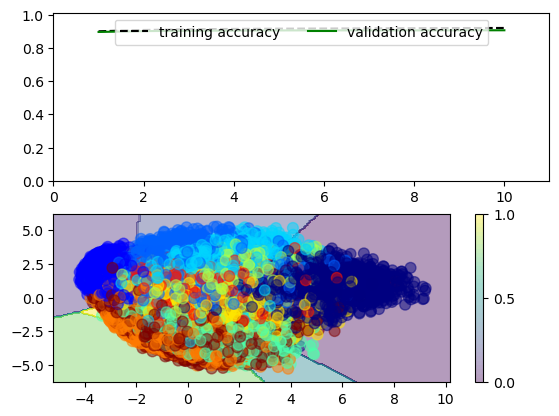

In [104]:
np.random.seed(0)
weight_history = [] # reset weight history for new training session

net = Net()
net.add(Linear(784, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

weight_history_1layer = weight_history.copy() # Store the weight history for the 1-layer network

# Two-layer Perceptron

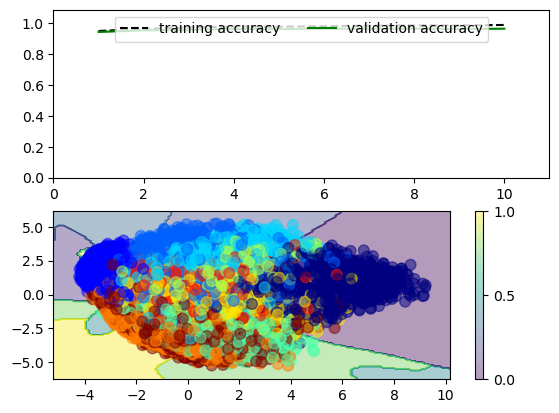

In [105]:
np.random.seed(0)
weight_history = [] # reset weight history for new training session

net = Net()
net.add(Linear(784, 100))
net.add(Tanh())
net.add(Linear(100, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

weight_history_2layer = weight_history.copy() # Store the weight history for the 2-layer network

# Three-layer Perceptron

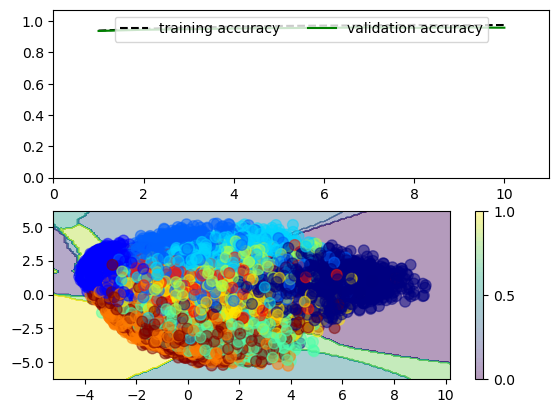

In [106]:
np.random.seed(0)
weight_history = [] # reset weight history for new training session

net = Net()
net.add(Linear(784, 100))
net.add(Tanh())
net.add(Linear(100, 50))
net.add(Tanh())
net.add(Linear(50, 10))
net.add(Softmax())

res = train_and_plot(10, net, loss=CrossEntropyLoss(), batch_size=4, lr=0.1)

weight_history_3layer = weight_history.copy() # Store the weight history for the 3-layer network

# Questions and Answers

1. Does the inter-layer activation function affect network performance?

    - Yes. Using Tanh improves accuracy because it enables better gradient flow during backpropagation. As layers increase, Tanh allows the network to learn more complex, curved decision boundaries.

2. Do we need 2- or 3-layered network for this task?

    - By comparing the graphs, the 2-layered network is more appropriate. The 3-layered network showed only minor accuracy improvement, meaning the extra complexity isn't justified for this task. Both can work, but the 2-layer is simpler and faster.

3. Did you experience any problems training the network? Especially as the 4. number of layers increased.

    - Yes. As layers increased, training became slower and the initial accuracy ramp-up took longer.

4. How do weights of the network behave during training? You may plot max abs value of weights vs. epoch to understand the relation.

    - The maximum absolute value of the weights generally increases over the training epochs, showing that the network is learning and updating its parameters. In the 1-layered network, the weights increase steadily throughout training. In the 2-layered network, both layers show increasing weights, with the last layer having consistently larger weights. In the 3-layered network, the weights initially increase in all layers, but the last layer begins to stabilise and slightly decreases towards the end, indicating that the layer is making smaller adjustments as training progresses. Overall, the weights grow gradually during training without signs of instability.


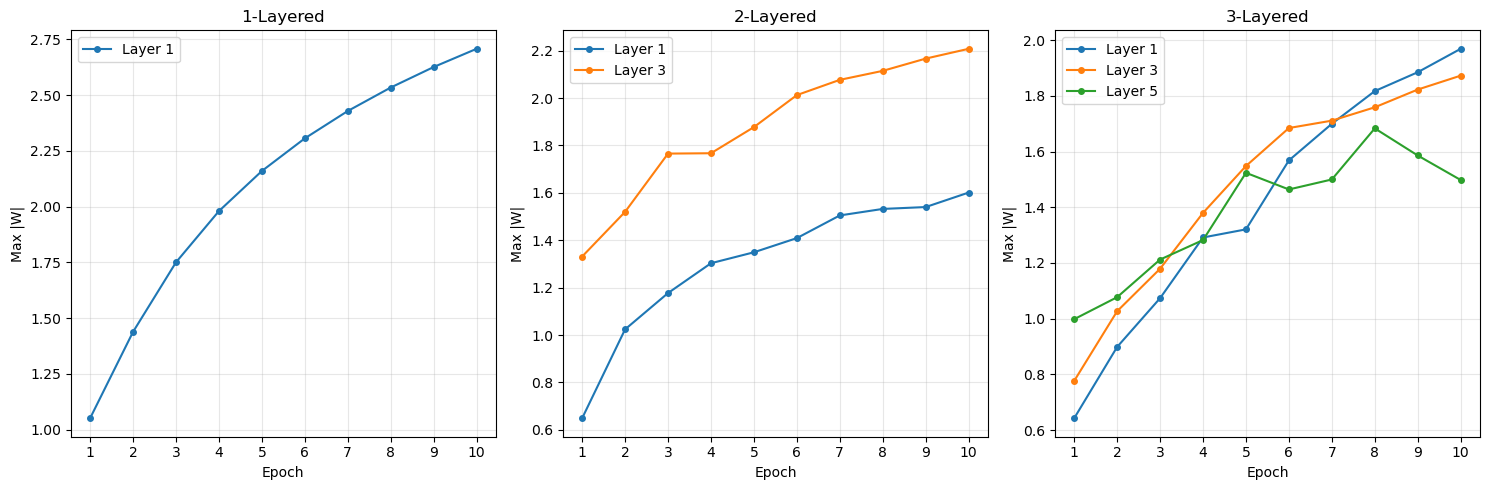

In [108]:
# Plot all three networks together
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

all_histories = [
    (weight_history_1layer, "1-Layered"),
    (weight_history_2layer, "2-Layered"),
    (weight_history_3layer, "3-Layered")
]

for ax, (wh, title) in zip(axes, all_histories):
    if len(wh) > 0:
        epochs = range(1, len(wh) + 1)
        for layer_name in wh[0].keys():
            values = [e[layer_name] for e in wh]
            ax.plot(epochs, values, label=layer_name, marker='o', markersize=4)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Max |W|')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(1, len(wh) + 1))

plt.tight_layout()
plt.show()